# Fitting a power-law PDF to the density diagnostic trend

This is an extension of the `density_diagnostic_trends` notebook, with the aim to

1. Perform a least squares fit of the model to the data
2. Calculate the credibility regions of the model parameters via MCMC

Both can be handled by the `lmfit` library. 

All the classes and functions from `density_diagnostic_trends.ipynb` have been extracted into the `ddtrends.py` module. 

In [1]:
import numpy as np
from astropy.table import Table
from matplotlib import pyplot as plt
import seaborn as sns
import corner
from lmfit import Model
import ddtrends as ddt

In [2]:
sns.set_context("notebook")

## Empirical density trend for Orion

The following data was extracted from the Eduardo draft paper Figure 1, using ChatGPT

In [3]:
density_diagnostic_points = [
    # (diagnostic, log_nM, log_nobs, independent_subset)
    ("[S II] 6717/6731", 3.06, 2.309, True),
    ("[O II] 3727/3729", 3.16, 2.540, True),
    ("[Fe III] 4986/4881", 3.74, 2.685, True),
    ("[Fe III] 4658/4986", 3.84, 2.395, True),
    ("[Cl III] 5538/5518", 3.99, 3.070, True),
    ("[Fe III] 4986/4702", 4.04, 2.479, False),
    ("[S II] 4070/6717", 4.64, 2.593, False),
    ("[O II] 7320/3729", 4.69, 2.868, False),
    ("[S II] 4070/(6717+6731)", 4.85, 2.757, True),
    ("[S II] (4070+4075)/(6717+6731)", 4.91, 2.979, False),
    ("[O II] 7320/(3727+3729)", 5.03, 2.942, True),
    ("[O II] 7320/3727", 5.10, 3.127, False),
    ("[Fe III] 4702/4881", 6.19, 3.696, True),
    ("[Fe II] 8617/7155", 6.31, 3.333, True),
    ("[Fe III] 4658/4881", 6.36, 3.608, False),
    ("[Fe III] 4658/4702", 6.90, 3.457, False),
]

Convert to an `astropy.Table` for ease of management

In [4]:
ori_tab = Table(
    rows=density_diagnostic_points,
    names=[
        "ratio",
        "log10(n_M)",
        "log10(n_obs)",
        "independent?",
    ],
)

Display the full data table

In [5]:
ori_tab

ratio,log10(n_M),log10(n_obs),independent?
str30,float64,float64,bool
[S II] 6717/6731,3.06,2.309,True
[O II] 3727/3729,3.16,2.54,True
[Fe III] 4986/4881,3.74,2.685,True
[Fe III] 4658/4986,3.84,2.395,True
[Cl III] 5538/5518,3.99,3.07,True
[Fe III] 4986/4702,4.04,2.479,False
[S II] 4070/6717,4.64,2.593,False
[O II] 7320/3729,4.69,2.868,False
[S II] 4070/(6717+6731),4.85,2.757,True


Display the subset of points with ratios that are algebraically independent

In [6]:
subset = ori_tab["independent?"]
ori_tab[subset]

ratio,log10(n_M),log10(n_obs),independent?
str30,float64,float64,bool
[S II] 6717/6731,3.06,2.309,True
[O II] 3727/3729,3.16,2.54,True
[Fe III] 4986/4881,3.74,2.685,True
[Fe III] 4658/4986,3.84,2.395,True
[Cl III] 5538/5518,3.99,3.07,True
[S II] 4070/(6717+6731),4.85,2.757,True
[O II] 7320/(3727+3729),5.03,2.942,True
[Fe III] 4702/4881,6.19,3.696,True
[Fe II] 8617/7155,6.31,3.333,True


Plot the data with the linear trend fit and 95% confidence interval

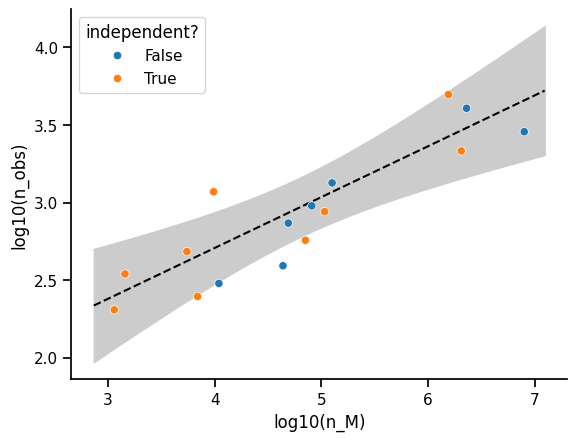

In [7]:
ax = sns.scatterplot(ori_tab.to_pandas(), x="log10(n_M)", y="log10(n_obs)", hue="independent?")
xx = np.linspace(*ax.get_xlim())
ax.plot(xx, np.log10(ddt.n_obs_improved_fit(10**xx)), color="k", ls="dashed", zorder=0)
ax.fill_between(
    xx,
    np.log10(ddt.n_obs_improved_fit(10**xx, line_type="lower")),
    np.log10(ddt.n_obs_improved_fit(10**xx, line_type="upper")),
    color="0.8",
    zorder=-1,
)
sns.despine()

## Perform the fit to the data

Unlike in the previous notebook, we will work exclusively in log-log space.

First make convenient vectors of the data to be fitted.

In [8]:
xdata = ori_tab[subset]["log10(n_M)"].data
ydata = ori_tab[subset]["log10(n_obs)"].data
xdata, ydata

(array([3.06, 3.16, 3.74, 3.84, 3.99, 4.85, 5.03, 6.19, 6.31]),
 array([2.309, 2.54 , 2.685, 2.395, 3.07 , 2.757, 2.942, 3.696, 3.333]))

Define a `lmfit.Model` object for the power-law PDF

In [113]:
def plaw_model(x, m, log_n0, log_width):
    """
    Model function for log10_n_obs(log10_n_M) with parameters (m, log_n0, log_width)

    The upper bound on density is log_n1 = log_n0 + log_width

    We do not use log_n1 directly as a parameter since we want to make sure
    it is always greater than the lower bound. Also, it is very poorly constrained by the data

    Suitable for use with lmfit.Model
    """

    # Set up diagnostic line ratio parameters
    nM = 10 ** x
    # Vary with nM = 1e3 -> 1e7 as delta = 2 -> 200
    delta = 2.0 * np.sqrt(nM / 1e3)

    # Set up power-law PDF
    log_n1 = log_n0 + log_width
    pdf = ddt.PowerLawPDF(m, 10 ** log_n0, 10 ** log_n1)

    # Find observed density using the vectorized function
    n_obs = ddt.n_app_from_nM(nM, pdf, delta=delta)

    return np.log10(n_obs)
    

pmodel = Model(plaw_model)

In [114]:
pmodel.param_names, pmodel.independent_vars

(['m', 'log_n0', 'log_width'], ['x'])

Set initial values for parameters. We restrict the values, but over a broad range of:
* $m = [-2.0, +2.0]$
* $\log_{10} n_0 = [-3.0, +3.0]$
* $\log_{10} n_1 = [+3.0, +9.0]$

This is only important for the upper limit, which otherwise tends to go ridiculously high. 

In [115]:
params = pmodel.make_params(
    m=dict(value=-0.5, min=-3, max=0.5),
    log_n0=dict(value=-1.0, min=-3, max=3.5),
    log_width=dict(value=5.0, min=0.1, max=12),
)
params

name,value,initial value,min,max,vary
m,-0.50000000,-0.5,-3.00000000,0.50000000,True
log_n0,-1.00000000,-1.0,-3.00000000,3.50000000,True
log_width,5.00000000,5.0,0.10000000,12.0000000,True


Fit model to the data

In [116]:
sig_y = 0.25 * np.ones_like(ydata)

In [117]:
result = pmodel.fit(ydata, params, x=xdata, weights=1 / sig_y)

In [118]:
result

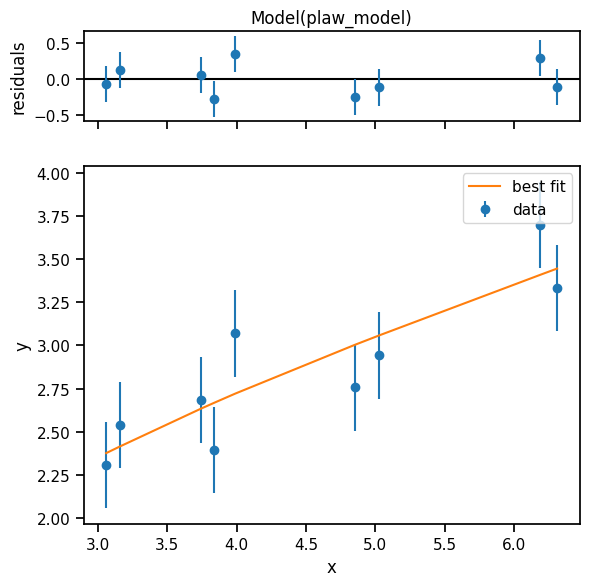

In [104]:
result.plot();

So the best-fit values of power-law slope $m = -1.4 \pm 0.2$ and lower density bound $\log_{10} n_0 = 1.6 \pm 0.5$ are very similar to the values found by hand in the previous notebook.

However, the upper density bound gets stuck at the highest allowed value $\log_{10} n_0 = 9.0$ with a nonsensical error estimate.

## Find credibile bounds on PDF parameters with MCMC

Use the `emcee` method, starting from the parameters of the previous fit.

In [119]:
mcmc_params = result.params.copy()
#mcmc_params.add("__lnsigma", value=np.log(0.1), min=np.log(0.001), max=np.log(1))

In [120]:
mcmc_result = pmodel.fit(
    data=ydata,
    x=xdata,
    weights=1 / sig_y,
    params=mcmc_params,
    method="emcee",
    steps=50000,                         # Total MCMC steps per walker
    burn=10000,                           # Discard early unstable steps
    thin=10,                            # Only save every 10th sample to save memory
    is_weighted=True,               # Set False if errors are unknown/estimated
    workers=16,
    seed=2026_06_09,
) 

/Users/will/Dropbox/hii-density-distribution/.venv/lib/python3.14/site-packages/lmfit/model.py:1127: UserWarning: The keyword argument steps does not match any arguments of the model function. It will be ignored.
  warnings.warn(f"The keyword argument {name} does not " +
/Users/will/Dropbox/hii-density-distribution/.venv/lib/python3.14/site-packages/lmfit/model.py:1127: UserWarning: The keyword argument burn does not match any arguments of the model function. It will be ignored.
  warnings.warn(f"The keyword argument {name} does not " +
/Users/will/Dropbox/hii-density-distribution/.venv/lib/python3.14/site-packages/lmfit/model.py:1127: UserWarning: The keyword argument thin does not match any arguments of the model function. It will be ignored.
  warnings.warn(f"The keyword argument {name} does not " +
/Users/will/Dropbox/hii-density-distribution/.venv/lib/python3.14/site-packages/lmfit/model.py:1127: UserWarning: The keyword argument is_weighted does not match any arguments of the mod

The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [51.05125818 48.71983176 46.62989539]


In [121]:
mcmc_result

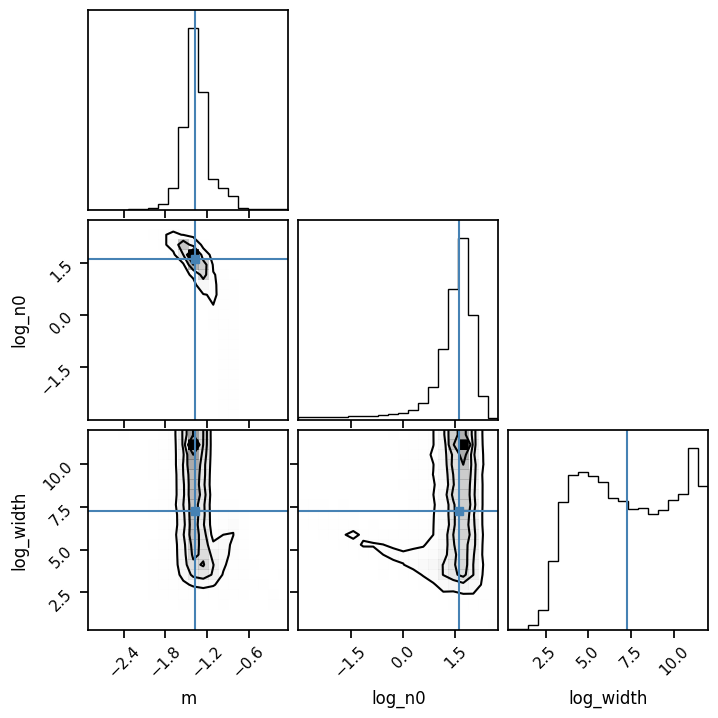

In [170]:
corner.corner(
    mcmc_result.flatchain, 
    labels=mcmc_result.var_names, 
    truths=[mcmc_result.params[p].value for p in mcmc_result.var_names],
    plot_datapoints=False,
);

In [123]:
result.params

name,value,standard error,relative error,initial value,min,max,vary
m,-1.38652364,0.20356401,(14.68%),-0.5,-3.00000000,0.50000000,True
log_n0,1.62452610,0.46417374,(28.57%),-1.0,-3.00000000,3.50000000,True
log_width,11.1126665,13426552.0,(120822054.62%),5.0,0.10000000,12.0000000,True


In [124]:
mcmc_result.params

name,value,standard error,relative error,initial value,min,max,vary
m,-1.36668331,0.15809442,(11.57%),-1.3865236365262705,-3.00000000,0.50000000,True
log_n0,1.59496699,0.47084354,(29.52%),1.6245260980357559,-3.00000000,3.50000000,True
log_width,7.26423964,3.22617276,(44.41%),11.11266652311189,0.10000000,12.0000000,True


In [130]:
fc = mcmc_result.flatchain
print("quantile", *mcmc_result.var_names)
for q in [0.05, 0.16, 0.50, 0.84, 0.95]:
    print(q, *[f"{fc[p].quantile(q):.2f}" for p in mcmc_result.var_names] )

quantile m log_n0 log_width
0.05 -1.64 -0.30 3.32
0.16 -1.51 1.00 4.31
0.5 -1.37 1.59 7.26
0.84 -1.20 1.94 10.74
0.95 -0.94 2.13 11.56


In [63]:
np.percentile(fc["log_width"], [5, 16, 50])

array([3.55107928, 4.40923597, 7.2846419 ])

In [165]:
posterior_samples = mcmc_result.flatchain.sample(n=1000, random_state=42)

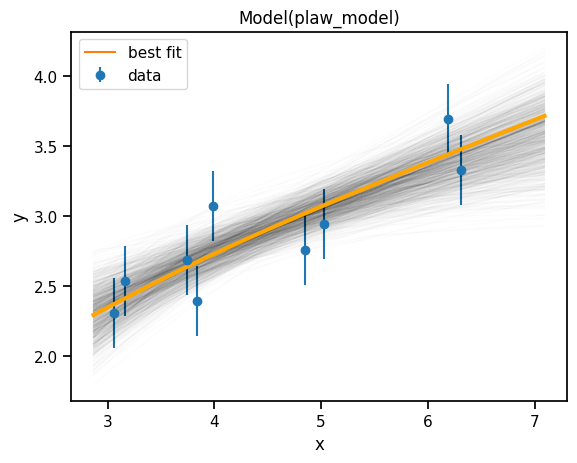

In [167]:
g = mcmc_result.plot_fit()
for d in posterior_samples.to_dict(orient="records"):
    g.plot(xx, mcmc_result.eval(x=xx, **d), alpha=0.01, lw=1, color="k")
g.plot(xx, mcmc_result.eval(x=xx), lw=3, color="orange")

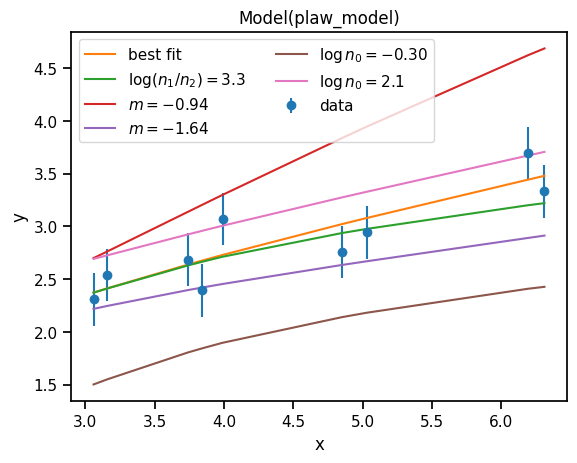

In [140]:
g = mcmc_result.plot_fit()
g.plot(xdata, mcmc_result.eval(x=xdata, log_width=3.3), label=r"$\log(n_1/n_2) = 3.3$")
g.plot(xdata, mcmc_result.eval(x=xdata, m=-0.94), label="$m = -0.94$")
g.plot(xdata, mcmc_result.eval(x=xdata, m=-1.64), label="$m = -1.64$")
g.plot(xdata, mcmc_result.eval(x=xdata, log_n0=-0.30, log_width=5.0), label=r"$\log n_0 = -0.30$")
g.plot(xdata, mcmc_result.eval(x=xdata, log_n0=2.13), label=r"$\log n_0 = 2.1$")

g.legend(ncol=2)

A prettier corner plot

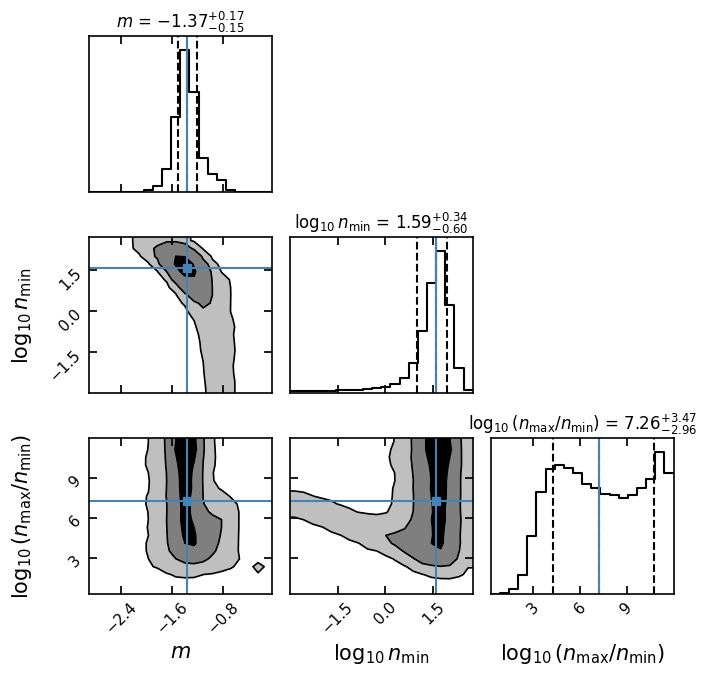

In [185]:
samples = mcmc_result.flatchain[["m", "log_n0", "log_width"]]
labels = [
    r"$m$",
    r"$\log_{10} n_\min$",
    r"$\log_{10}(n_\max/n_\min)$",
]
fig = corner.corner(
    samples,
    labels=labels,
    truths=[
        np.median(samples["m"]),
        np.median(samples["log_n0"]),
        np.median(samples["log_width"]),
    ],
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 15},
    # Main aesthetic improvements
    plot_datapoints=False,
    fill_contours=True,
    smooth=0.7,
    smooth1d=0.5,
    # Contours approximately enclosing 1, 2, 3 sigma for 2D Gaussian
    levels=(0.393, 0.865, 0.989),
    contour_kwargs={
        "linewidths": 1.2,
    },
    # Axis/tick control
    max_n_ticks=4,
    top_ticks=False,
)

fig.set_size_inches(7.0, 7.0)
fig.tight_layout()